## **2D Quantum Confinement**

An $8\times8$ box with silicon anisotropic masses $t_1=1/0.19$, $t_2=1/0.98$.

### **Set Problem**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qconflib import problem_2d

nx = ny = 3                                   # 8 x 8 grid, 6 qubits
prob = problem_2d(nx, ny)                     # silicon masses by default
print(prob.label)
print(f"qubits {prob.n}  ->  {2**nx} x {2**ny} grid points")
print("sub-registers (start, size, t):", prob.dims)
print(f"ground-state energy {prob.lam_min:.5f}")

2D box 8x8, t1=5.263, t2=1.020
qubits 6  ->  8 x 8 grid points
sub-registers (start, size, t): [(0, 3, 5.2631578947368425), (3, 3, 1.0204081632653061)]
ground-state energy 0.75789


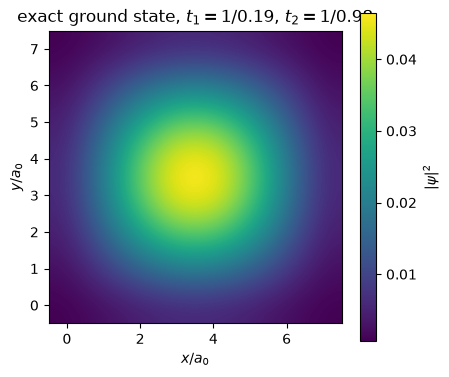

In [2]:
exact2d = (np.abs(prob.ground)**2).reshape(2**ny, 2**nx)
plt.figure(figsize=(4.6, 4))
plt.imshow(exact2d, origin='lower', cmap='viridis', interpolation='bicubic')
plt.colorbar(label=r'$|\psi|^2$')
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$y/a_0$')
plt.title(r'exact ground state, $t_1{=}1/0.19$, $t_2{=}1/0.98$')
plt.tight_layout(); plt.show()

### **Measurement Cost in 2D**

Each direction is measured on its own sub-register, so the circuit counts add.

In [3]:
# --- measurement circuits, local copy -------------------------------------------------
# The logical circuits an estimator runs, before transpilation. Mirrors
# BatchedExpectation._dir_circuits (qconflib/gradients.py); each notebook that draws or
# counts circuits carries its own identical copy, so nothing here is imported across
# notebooks.
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qconflib import make_HEA, QFT_LNN, increment


def measurement_circuits(problem, method, depth=1, theta=None):
    """Order: one group per direction in problem.dims (SD -> m circuits, PO/FD -> 2),
    then the density circuit if the problem carries a potential.
    theta: bind these parameters; None leaves the ParameterVector symbolic."""
    n = problem.n
    pv = ParameterVector('t', n * depth)
    u = make_HEA(n, depth, pv).to_gate(label='U')
    circs = []
    for start, m, _ in problem.dims:
        if method == 'SD':
            for j in range(m):
                mm = m - j
                qc = QuantumCircuit(n, mm)
                qc.append(u, qc.qubits)
                for i in range(m - j - 1):
                    qc.cx(start + i + 1, start + i)
                qc.h(start + m - 1 - j)
                qc.measure(range(start, start + mm), range(mm))
                circs.append(qc)
        elif method == 'FD':
            qc = QuantumCircuit(n + 1, 1)
            qc.append(u, qc.qubits[:n])
            QFT_LNN(qc, m, start); qc.h(n)
            for idx in range(m):
                qc.cp((2 * np.pi / (2**m)) * (2**idx), n, start + m - 1 - idx)
            qc.h(n); qc.measure(n, 0)
            qc2 = QuantumCircuit(n, m)
            qc2.append(u, qc2.qubits)
            increment(qc2, m, start); qc2.h(start)
            qc2.measure(range(start, start + m), range(m))
            circs += [qc, qc2]
        elif method == 'PO':
            c1 = QuantumCircuit(n, 1)
            c1.append(u, c1.qubits)
            c1.h(start); c1.measure(start, 0)
            c2 = QuantumCircuit(n, m)
            c2.append(u, c2.qubits)
            increment(c2, m, start); c2.h(start)
            c2.measure(range(start, start + m), range(m))
            circs += [c1, c2]
        else:
            raise ValueError(f"unknown method {method}")
    if problem.ux is not None:
        qc = QuantumCircuit(n, n)
        qc.append(u, qc.qubits)
        qc.measure(range(n), range(n))
        circs.append(qc)
    if theta is not None:
        b = dict(zip(pv, theta))
        return [c.assign_parameters(b) for c in circs]
    return circs

from qconflib import n_circuits

for m in ('PO', 'SD', 'FD'):
    print(f"{m}: {n_circuits(m, prob)} circuits per <H> evaluation")

print("\nSD circuits, grouped by direction:")
sd = measurement_circuits(prob, 'SD', depth=1)
for j, c in enumerate(sd):
    meas = sorted({c.find_bit(i.qubits[0]).index for i in c.data
                   if i.operation.name == 'measure'})
    direction = 'x' if min(meas) < nx else 'y'
    print(f"  circuit {j}: measures qubits {meas}  -> direction {direction}")

PO: 4 circuits per <H> evaluation
SD: 6 circuits per <H> evaluation
FD: 4 circuits per <H> evaluation

SD circuits, grouped by direction:
  circuit 0: measures qubits [0, 1, 2]  -> direction x
  circuit 1: measures qubits [0, 1]  -> direction x
  circuit 2: measures qubits [0]  -> direction x
  circuit 3: measures qubits [3, 4, 5]  -> direction y
  circuit 4: measures qubits [3, 4]  -> direction y
  circuit 5: measures qubits [3]  -> direction y


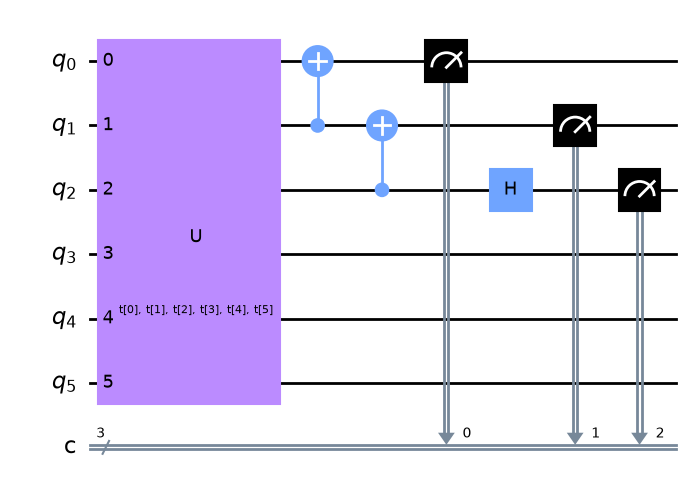

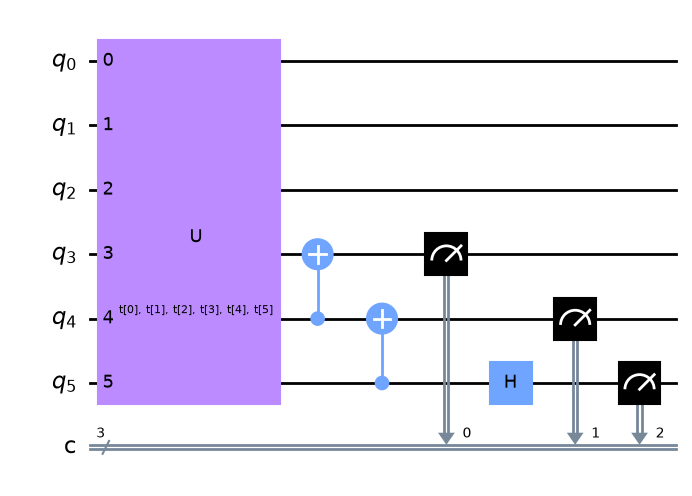

In [4]:
# one circuit from each direction, side by side
display(sd[0].draw('mpl', style='clifford', fold=-1))    # x sub-register
display(sd[nx].draw('mpl', style='clifford', fold=-1))   # y sub-register

### **Train**

In [5]:
from qconflib import solve
import time

depth = 4
runs = {}
for m in ('SD', 'FD'):
    t0 = time.perf_counter()
    runs[m] = solve(prob, method=m, depth=depth, shots=2**14, seed=111,
                    stages=((120, 2**14),), screen=8)
    print(f"{m}: trace {runs[m]['trace']:.4f}, energy {runs[m]['energy']:.5f} "
          f"(exact {prob.lam_min:.5f})   [{time.perf_counter()-t0:.0f} s]")

SD: trace 0.0381, energy 0.76426 (exact 0.75789)   [173 s]


FD: trace 0.0267, energy 0.76239 (exact 0.75789)   [125 s]


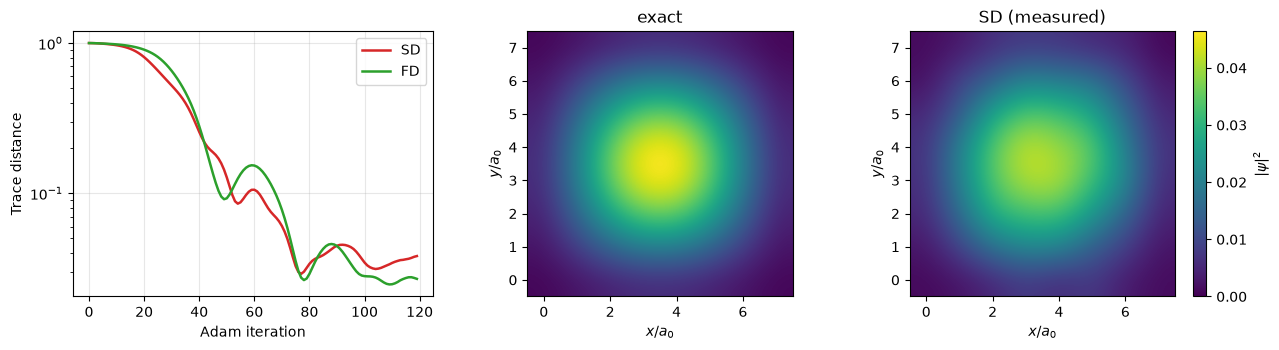

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for m, c in [('SD', '#d62728'), ('FD', '#2ca02c')]:
    ax[0].semilogy([h[2] for h in runs[m]['history']], color=c, lw=1.8, label=m)
ax[0].set_xlabel('Adam iteration'); ax[0].set_ylabel('Trace distance')
ax[0].grid(alpha=.3); ax[0].legend()

for k, (title, grid) in enumerate([('exact', exact2d),
                                   ('SD (measured)', runs['SD']['rho'].reshape(2**ny, 2**nx))]):
    im = ax[k+1].imshow(grid, origin='lower', cmap='viridis', interpolation='bicubic',
                        vmin=0, vmax=exact2d.max())
    ax[k+1].set_title(title); ax[k+1].set_xlabel(r'$x/a_0$'); ax[k+1].set_ylabel(r'$y/a_0$')
fig.colorbar(im, ax=ax[2], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()

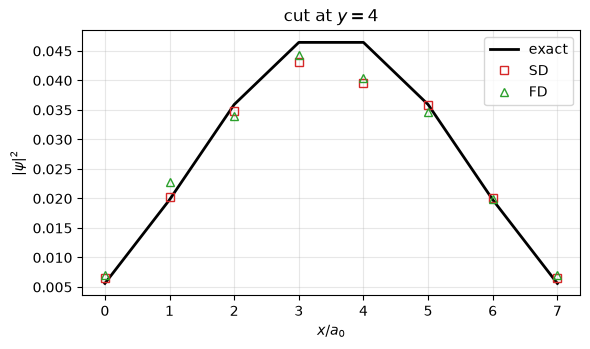

In [7]:
# a cut through the middle row makes the agreement quantitative
row = 2**ny // 2
plt.figure(figsize=(6, 3.6))
plt.plot(np.arange(2**nx), exact2d[row], 'k-', lw=2, label='exact')
for m, c, mk in [('SD', '#d62728', 's'), ('FD', '#2ca02c', '^')]:
    plt.plot(np.arange(2**nx), runs[m]['rho'].reshape(2**ny, 2**nx)[row], mk,
             color=c, mfc='none', label=m)
plt.xlabel(r'$x/a_0$'); plt.ylabel(r'$|\psi|^2$'); plt.title(f'cut at $y={row}$')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

### **Flat vs Coarse-to-Fine Shot Schedule**

At 16x16, FD stalls on the plateau at a flat $2^{20}$ budget: the Hadamard-test variance $\propto 1-\langle Z\rangle^2$ is largest exactly there. A coarse-to-fine schedule fixes it at lower total cost.

In [8]:
import json, os

flat = os.path.join('paper', 'data', 'flat2p20_plateau')
staged = os.path.join('paper', 'data', 'prod')

m_flat = json.load(open(f'{flat}/r_2d_16x16_meta.json'))
m_stag = json.load(open(f'{staged}/r_2d_16x16_staged3_meta.json'))
print("flat 2^20 for 300 iterations:")
print("   stages:", m_flat['args']['stages'], "->",
      {k: round(v['trace'], 4) for k, v in m_flat['terminal'].items()})
print("coarse-to-fine schedule:")
print("   stages:", m_stag['args']['stages'], "->",
      {k: round(v['trace'], 4) for k, v in m_stag['terminal'].items()})

flat 2^20 for 300 iterations:
   stages: 300:1048576 -> {'classical': 0.0008, 'SD': 0.0364, 'FD': 0.7783}
coarse-to-fine schedule:
   stages: 100:65536,100:262144,100:1048576 -> {'classical': 0.0008, 'SD': 0.6714, 'FD': 0.051}


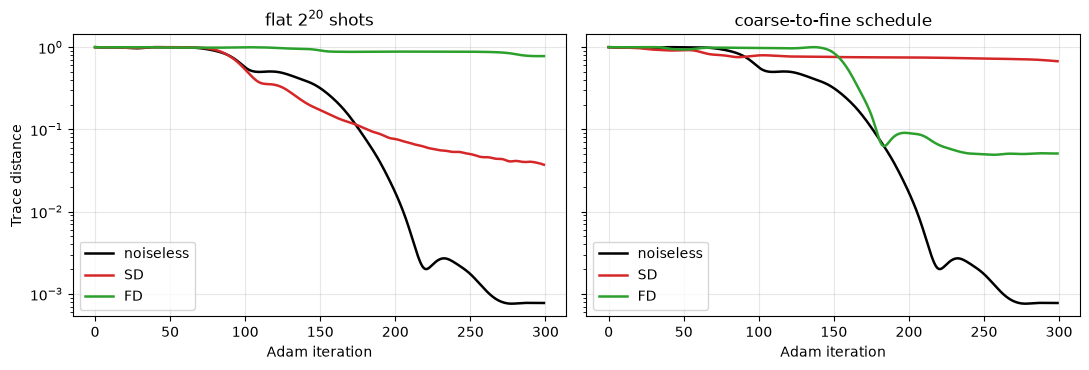

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for k, (tag, D, title) in enumerate([('flat', flat, r'flat $2^{20}$ shots'),
                                     ('staged', staged, 'coarse-to-fine schedule')]):
    stem = 'r_2d_16x16' if tag == 'flat' else 'r_2d_16x16_staged3'
    for m, c, lab in [('classical', 'k', 'noiseless'), ('SD', '#d62728', 'SD'),
                      ('FD', '#2ca02c', 'FD')]:
        f = f'{D}/{stem}_history_{m}.csv'
        if not os.path.exists(f):
            continue
        h = np.loadtxt(f, delimiter=',', skiprows=1)
        ax[k].semilogy(h[:, 2], color=c, lw=1.8, label=lab)
    ax[k].set_title(title); ax[k].set_xlabel('Adam iteration'); ax[k].grid(alpha=.3)
    ax[k].legend()
ax[0].set_ylabel('Trace distance')
plt.tight_layout(); plt.show()

### **Production Run (32x32)**

2D box 32x32, t1=5.263, t2=1.020
terminal : {'classical': 0.0205, 'SD': 0.0503, 'FD': 0.0366}
wall time: {'classical': '0 min', 'SD': '121 min', 'FD': '49 min'}


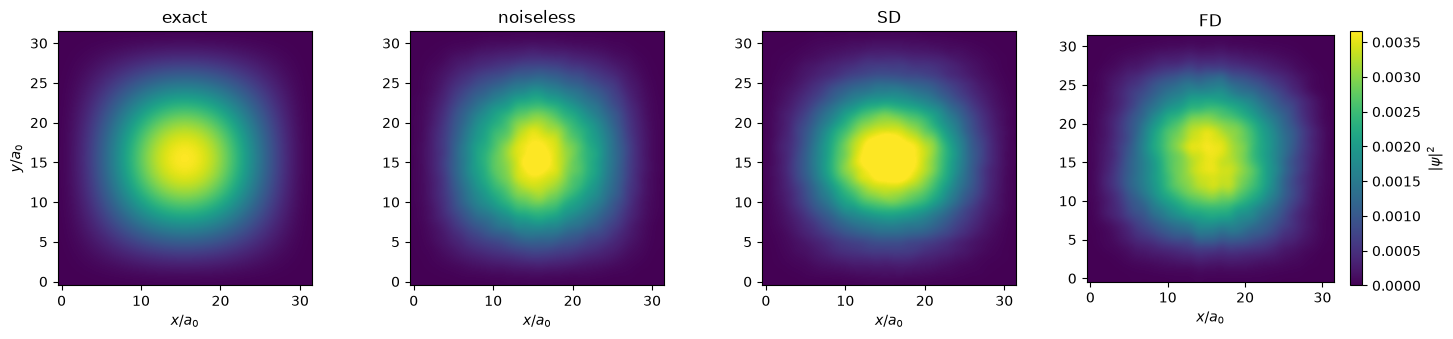

In [10]:
D = os.path.join('paper', 'data', 'prod')
meta = json.load(open(f'{D}/r_2d_32x32_staged_meta.json'))
print(meta['label'])
print('terminal :', {k: round(v['trace'], 4) for k, v in meta['terminal'].items()})
print('wall time:', {k: f'{v/60:.0f} min' for k, v in meta['time_s'].items()})

grids = {m: np.loadtxt(f'{D}/r_2d_32x32_staged_density_{m}.csv', delimiter=',').reshape(32, 32)
         for m in ('classical', 'SD', 'FD')}
p32 = problem_2d(5, 5)
grids['exact'] = (np.abs(p32.ground)**2).reshape(32, 32)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for k, name in enumerate(['exact', 'classical', 'SD', 'FD']):
    im = ax[k].imshow(grids[name], origin='lower', cmap='viridis', interpolation='bicubic',
                      vmin=0, vmax=grids['exact'].max())
    ax[k].set_title('noiseless' if name == 'classical' else name)
    ax[k].set_xlabel(r'$x/a_0$')
ax[0].set_ylabel(r'$y/a_0$')
fig.colorbar(im, ax=ax[3], label=r'$|\psi|^2$')
plt.tight_layout(); plt.show()